# PyTorch and HuggingFace on ARM M1 MacOS

The code bellow comes from https://github.com/jamescalam/pytorch-mps/blob/main/code/00_setup_and_speed.ipynb.<br>
Last update: August 5, 2022

Running PyTorch on MPS requires MacOS 12.3+ and the ARM version of Python installed. We can check the MacOS version with:

In [20]:
import sys
import numpy as np

import platform
print (platform.platform())

print ("Python Version:{}".format(sys.version))
print ("NumPy Version:{}".format(np.__version__))

# We should see 
# macOS-12.4-arm64-arm-64bit

macOS-12.5-arm64-i386-64bit
Python Version:3.9.13 | packaged by conda-forge | (main, May 27 2022, 17:01:00) 
[Clang 13.0.1 ]
NumPy Version:1.23.1


In [21]:
import torch

torch.device("mps")
print(torch.__version__)
print(torch.tensor([1,2,3], device="mps"))
print (torch.has_mps)

1.13.0.dev20220805
tensor([1, 2, 3], device='mps:0')
True


In [22]:
import platform; platform.mac_ver()
# Should be ('12.4', ('', '', ''), 'arm64')

('12.5', ('', '', ''), 'arm64')

In [23]:
# this ensures that the current MacOS version is at least 12.3+
print(torch.backends.mps.is_available())

# this ensures that the current current PyTorch installation was built with MPS activated.
print(torch.backends.mps.is_built())

True
True


In [24]:
import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

In [25]:
torch.has_mps

True

In [26]:
# load the first 1K rows of the TREC dataset
trec = load_dataset('trec', split='train[:1000]')
trec

Using custom data configuration default
Reusing dataset trec (/Users/boisalai/.cache/huggingface/datasets/trec/default/1.1.0/751da1ab101b8d297a3d6e9c79ee9b0173ff94c4497b75677b59b61d5467a9b9)


Dataset({
    features: ['label-coarse', 'label-fine', 'text'],
    num_rows: 1000
})

In [27]:
trec[0]

{'label-coarse': 0,
 'label-fine': 0,
 'text': 'How did serfdom develop in and then leave Russia ?'}

In [28]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [29]:
# take the first 64 rows of the trec data
text = trec['text'][:64]
# tokenize text using the BERT tokenizer
tokens = tokenizer(
    text, max_length=512,
    truncation=True, padding=True,
    return_tensors='pt'
)

In [30]:
%%timeit
model(**tokens)

360 ms ± 7.75 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [31]:
device = torch.device('mps')
model.to(device)
tokens.to(device)
device

device(type='mps')

In [32]:
%%timeit
model(**tokens)

140 ms ± 1.13 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [33]:
text = trec['text'][:256]
tokens = tokenizer(
    text, max_length=512,
    truncation=True, padding=True,
    return_tensors='pt'
)

device = torch.device('cpu')
model.to(device)
device

device(type='cpu')

In [34]:
%%timeit
model(**tokens)

2.09 s ± 405 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [35]:
device = torch.device('mps')
model.to(device)
tokens.to(device)
device

device(type='mps')

In [36]:
%%timeit
model(**tokens)

The slowest run took 11.13 times longer than the fastest. This could mean that an intermediate result is being cached.
1.46 s ± 2.02 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [37]:
from time import time

reruns = 6
b = 10

# start with CPU test
device = torch.device('cpu')
model.to(device)

cpu_times = []

for i in range(b):
    text = trec['text'][:2**i]
    tokens = tokenizer(
        text, max_length=512,
        truncation=True, padding=True,
        return_tensors='pt'
    )
    tot_time = 0
    for _ in range(reruns):
        t0 = time()
        model(**tokens)
        tot_time += time()-t0
    cpu_times.append(tot_time/reruns)

# then GPU test
device = torch.device('mps')
model.to(device)

mps_times = []

for i in range(b):
    text = trec['text'][:2**i]
    tokens = tokenizer(
        text, max_length=512,
        truncation=True, padding=True,
        return_tensors='pt'
    ).to(device)
    tot_time = 0
    for _ in range(reruns):
        t0 = time()
        model(**tokens)
        tot_time += time()-t0
    mps_times.append(tot_time/reruns)

<AxesSubplot:>

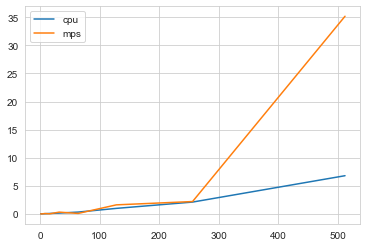

In [38]:
import seaborn as sns

sns.set_style('whitegrid')

sns.lineplot(
    x=[2**i for i in range(b)]*2,
    y=cpu_times+mps_times,
    hue=['cpu']*b + ['mps']*b
)